In [1]:
#testing the ODEsolving etc.

In [1]:
import scipy
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt
import itertools
import time

In [2]:
all_df = pd.read_csv('GSE124821_data_1e8.csv')
T11_df = all_df[all_df['Cell_Line']=="T11"]

In [3]:
T11_df

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
118,SRX5100724,0.001480,0.000810,0.000054,0.000361,antiPD1; antiCTLA4;,Apobec_end,end,GSM3554847,T11
119,SRX5100723,0.003149,0.001488,0.000000,0.000462,no_treatment,UV_end,end,GSM3554848,T11
120,SRX5100722,0.003321,0.001212,0.000111,0.000485,no_treatment,Apobec_day3,day3,GSM3554849,T11
121,SRX5100642,0.002127,0.001080,0.000074,0.000376,antiPD1; antiCTLA4;,Apobec_end,end,GSM3554850,T11
122,SRX5100641,0.002820,0.001231,0.000345,0.000426,no_treatment,UV_end,end,GSM3554851,T11
...,...,...,...,...,...,...,...,...,...,...
187,SRX5100807,0.003208,0.001269,0.000000,0.000442,antiPD1; antiCTLA4;,end,end,GSM3554932,T11
188,SRX5100814,0.002745,0.001124,0.000000,0.000464,antiPD1; antiCTLA4;,end,end,GSM3554933,T11
189,SRX5100813,0.002178,0.000910,0.000000,0.000339,no_treatment,end,end,GSM3554934,T11
190,SRX5100812,0.002956,0.001310,0.000041,0.000505,no_treatment,end,end,GSM3554935,T11



Number of replicates 12
Dendritic_quanTIseq    0.003080
NK_quanTIseq           0.001281
T.CD8_quanTIseq        0.000083
Tregs_quanTIseq        0.000488
dtype: float64
<class 'pandas.Series'>
0.004931670351666666

Number of replicates 12
Dendritic_quanTIseq    0.002800
NK_quanTIseq           0.001195
T.CD8_quanTIseq        0.000036
Tregs_quanTIseq        0.000409
dtype: float64
<class 'pandas.Series'>
0.004439672810000001

Number of replicates 13
Dendritic_quanTIseq    0.002509
NK_quanTIseq           0.001151
T.CD8_quanTIseq        0.000033
Tregs_quanTIseq        0.000401
dtype: float64
<class 'pandas.Series'>
0.004093501202615385

Number of replicates 7
Dendritic_quanTIseq    0.004187
NK_quanTIseq           0.001479
T.CD8_quanTIseq        0.000074
Tregs_quanTIseq        0.000443
dtype: float64
<class 'pandas.Series'>
0.006182992517142857

Number of replicates 8
Dendritic_quanTIseq    0.004660
NK_quanTIseq           0.001701
T.CD8_quanTIseq        0.000798
Tregs_quanTIseq        0.0006

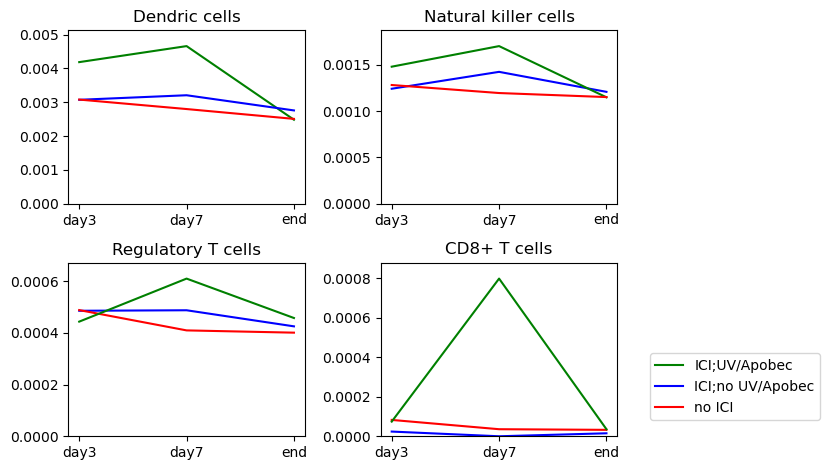

In [4]:


treatment_df = T11_df[T11_df['Mouse_treatment']!="no_treatment"]
no_treatment_df = T11_df[T11_df['Mouse_treatment']=="no_treatment"]

quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]

time_points = ["day3","day7","end"]

# no treatment (mutagen and no mutagen together)
no_treatment_Ds = []
no_treatment_NKs = []
no_treatment_T8s = []
no_treatment_Tregs = []

scatter_no_treatment_Ds = []
scatter_no_treatment_NKs = []
scatter_no_treatment_Tregs = []
scatter_no_treatment_T8s = []
scatter_no_treatment_times = []
for day in time_points:
    day_df = no_treatment_df[no_treatment_df['Condition'].str.contains(day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    no_treatment_Ds.append(averages["Dendritic_quanTIseq"])
    no_treatment_NKs.append(averages["NK_quanTIseq"])
    no_treatment_T8s.append(averages["T.CD8_quanTIseq"])
    no_treatment_Tregs.append(averages["Tregs_quanTIseq"])
    no_treatment_total = sum(averages)
    print(no_treatment_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_no_treatment_Ds.append(i)
                scatter_no_treatment_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_no_treatment_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_no_treatment_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_no_treatment_T8s.append(i)

#treatment with mutagen
mutagen_Ds = []
mutagen_NKs = []
mutagen_T8s = []
mutagen_Tregs = []

scatter_mutagen_Ds = []
scatter_mutagen_NKs = []
scatter_mutagen_Tregs = []
scatter_mutagen_T8s = []
scatter_mutagen_times = []
for day in time_points:
    day_df = treatment_df[treatment_df['Condition'].str.contains('_'+day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    mutagen_NKs.append(averages["NK_quanTIseq"])
    mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    mutagen_total = sum(averages)
    print(mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_mutagen_Ds.append(i)
                scatter_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_mutagen_T8s.append(i)


#treatment with mutagen
no_mutagen_Ds = []
no_mutagen_NKs = []
no_mutagen_T8s = []
no_mutagen_Tregs = []
scatter_no_mutagen_Ds = []
scatter_no_mutagen_NKs = []
scatter_no_mutagen_Tregs = []
scatter_no_mutagen_T8s = []
scatter_no_mutagen_times = []

for day in time_points:
    day_df = treatment_df[treatment_df['Condition']==day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    
    print(averages)
    stds = day_df.filter(items=quanTIseq_cols).std()
    
    # print(averages+stds)
    # print(averages-stds)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    no_mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    no_mutagen_NKs.append(averages["NK_quanTIseq"])
    no_mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    no_mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    no_mutagen_total = sum(averages)
    print(no_mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_no_mutagen_Ds.append(i)
                scatter_no_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_no_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_no_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_no_mutagen_T8s.append(i)

print(scatter_Ds)
fig,ax = plt.subplots(2,2)

Dplot = ax[0,0]
Dplot.plot(time_points,no_mutagen_mutagen_Ds,'g',label='ICI;UV/Apobec')
Dplot.plot(time_points,Ds,'b',label='ICI;no UV/Apobec')

Dplot.plot(time_points,no_treatment_Ds,'r',label='no ICI')
Dplot.set_title('Dendric cells')
Dplot.set_ylim(0.0,max([*no_mutagen_Ds,*mutagen_Ds,*no_treatment_Ds])*1.1)
handles,labels = Dplot.get_legend_handles_labels()
NKplot = ax[0,1]
NKplot.plot(time_points,no_mutagen_NKs,'b')
NKplot.plot(time_points,mutagen_NKs,'g')
NKplot.plot(time_points,no_treatment_NKs,'r')
NKplot.set_title('Natural killer cells')

NKplot.set_ylim(0.0,max([*no_mutagen_NKs,*mutagen_NKs,*no_treatment_NKs])*1.1)

Tregplot = ax[1,0]
Tregplot.plot(time_points,no_mutagen_Tregs,'b')
Tregplot.plot(time_points,no_treatment_Tregs,'r')
Tregplot.plot(time_points,mutagen_Tregs,'g')

Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0,max([*no_mutagen_Tregs,*mutagen_Tregs,*no_treatment_Tregs])*1.1)

T8plot = ax[1,1]
T8plot.plot(time_points,no_mutagen_T8s,'b')
T8plot.plot(time_points,no_treatment_T8s,'r')
T8plot.plot(time_points,mutagen_T8s,'g')

T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0,max([*no_mutagen_T8s,*mutagen_T8s,*no_treatment_T8s])*1.1)

fig.legend(handles,labels,bbox_to_anchor=(0.3, 0.1,1,1),loc = 'lower right')
plt.tight_layout()
plt.show()

In [27]:
import math

In [8]:
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC_comb,
               K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr_comb,d_T8,
              lambda_T8_comb,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC_comb*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr_comb*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8_comb*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))
def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    ) 
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
params = {'lambda_C':1.5,
          'C_M':0.8,
          'eta_8':328.25,
          'eta_N':300,
          'd_C':0.17,#0.17,
          'lambda_DC_comb':8e-5,
          # 'D_0':2e-5,
          'K_C':0.4,
          'd_D':0.1,
          'sigma_N':5e-5,
          'd_N':0.1,
          'gamma_N':150,
          'a_C':0.5,
          'beta_1':0.4,
          'beta_2':2e-4,
          'd_Tr':0.2,
          'lambda_Tr_comb':2e-4,
          'd_T8':0.18,
          'lambda_T8_comb':1.08e-3,
          'K_Tr':2.5e-4,
          'K_D':4e-4,
          'C_init':0.8,
          'D_init':0.0,
          'N_init':0.0,
          'Tr_init':0.0,
          'T8_init':0.0}
          

lambda_C   = params['lambda_C']
C_M        = params['C_M']
eta_8      = params['eta_8']
eta_N      = params['eta_N']
d_C            = params['d_C']
lambda_DC_comb = params['lambda_DC_comb']
# D_0            = params['D_0']
K_C        = params['K_C']
d_D        = params['d_D']
sigma_N    = params['sigma_N']
d_N        = params['d_N']
gamma_N    = params['gamma_N']
a_C        = params['a_C']
beta_1     = params['beta_1']
beta_2     = params['beta_2']
d_Tr       = params['d_Tr']
lambda_Tr_comb  = params['lambda_Tr_comb']
# Tr_0       = params['Tr_0']
d_T8       = params['d_T8']
lambda_T8_comb  = params['lambda_T8_comb']
# T8_0       = params['T8_0']
K_Tr       = params['K_Tr']
K_D        = params['K_D']


C_init     = params['C_init']
D_init     = params['D_init']
N_init     = params['N_init']
Tr_init    = params['Tr_init']
T8_init    = params['T8_init']
# eta_N = 300
# eta_8 = 328.2
# lambda_C = 1*lambda_C
# d_Tr = 1*d_Tr
# sigma_N = 2*sigma_N
# lambda_Tr = 2*lambda_Tr
# lamba_T8 = 2*lambda_T8



print(Ds)

def mean_square_error(y):
    error = 0
    if 'C' in objective_function_day3.keys():
        N = 2*5
        
        error+=(y[0,0]-objective_function_day3['C'])**2
        error+=(y[0,1]-objective_function_day7['C'])**2
    else:
        N = 2*4
    error+=(y[1,0]-objective_function_day3['Ds'])**2
    error+=(y[1,1]-objective_function_day7['Ds'])**2
    error+=(y[2,0]-objective_function_day3['NKs'])**2
    error+=(y[2,1]-objective_function_day7['NKs'])**2
    error+=(y[3,0]-objective_function_day3['Tregs'])**2
    error+=(y[3,1]-objective_function_day7['Tregs'])**2
    error+=(y[4,0]-objective_function_day3['T8s'])**2
    error+=(y[4,1]-objective_function_day7['T8s'])**2
    return math.sqrt(error/N)

def mean_square_error_rel(y):
    error = 0
    if 'C' in objective_function_day3.keys():
        N = 2*5 
        
        error+=((y[0,0]-objective_function_day3['C'])/y[0,0])**2
        error+=((y[0,1]-objective_function_day7['C'])/y[1,0])**2
    else:
        N = 2*4
    error+=((y[1,0]-objective_function_day3['Ds'])/y[1,0])**2
    error+=((y[1,1]-objective_function_day7['Ds'])/y[1,1])**2
    error+=((y[2,0]-objective_function_day3['NKs'])/y[2,0])**2
    error+=((y[2,1]-objective_function_day7['NKs'])/y[2,1])**2
    error+=((y[3,0]-objective_function_day3['Tregs'])/y[3,0])**2
    error+=((y[3,1]-objective_function_day7['Tregs'])/y[3,1])**2
    error+=((y[4,0]-objective_function_day3['T8s'])/y[4,0])**2
    error+=((y[4,1]-objective_function_day7['T8s'])/y[4,1])**2
    return math.sqrt(error/N)

def mean_square_error_rel(pred, true):
    return np.sqrt(np.mean(np.divide((pred - true),(pred)))**2)

[np.float64(0.0030734173499999996), np.float64(0.00320778915), np.float64(0.0027592482)]


In [9]:
# fitting UV treatment

In [27]:
objective_function_day3 = {'Ds':mutagen_Ds[0],
                          'NKs':mutagen_NKs[0],
                          'Tregs':mutagen_Tregs[0],
                          'T8s':mutagen_T8s[0]}
objective_function_day7 = {'Ds':mutagen_Ds[1],
                          'NKs':mutagen_NKs[1],
                          'Tregs':mutagen_Tregs[1],
                          'T8s':mutagen_T8s[1]}

true_mutagen = np.array([mutagen_Ds[:2],mutagen_NKs[:2],mutagen_Tregs[:2],mutagen_T8s[:2]])

In [31]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}


In [ ]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']
    

    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_mutagen)
        if minimum_distance>distance:
            minimum_distance = distance
            mutagen_best_params = params.copy()
            print(distance)
            print({k:mutagen_best_params[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:mutaven_best_params[k] for k in params_to_change.keys()})

58.54990152044953
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'K_Tr': 1e-05, 'd_N': 0.1}
48.29301373665286
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'K_Tr': 1.25e-05, 'd_N': 0.1}
41.42157868148067
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'K_Tr': 1.5e-05, 'd_N': 0.1}
32.77683576330905
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'K_Tr': 2e-05, 'd_N': 0.1}
29.876278028619808
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'K_Tr': 2.25e-05, 'd_N': 0.1}
24.03378271169997
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'K_Tr': 3e-05, 'd_N': 0.1}
23.37145698719538
{'lambda_T8_comb': 1e-05, 'lambda_DC_

In [41]:
print(mutagen_best_params)
print({k:mutagen_best_params[k] for k in params_to_change.keys()})

# mutagen_best_params = {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0005, 'd_N': 0.15, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.075, 'lambda_T8_comb': 0.00125, 'K_Tr': 3e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}

{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0005, 'd_N': 0.15, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.075, 'lambda_T8_comb': 0.00125, 'K_Tr': 3e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
{'lambda_T8_comb': 0.00125, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.075, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.15}


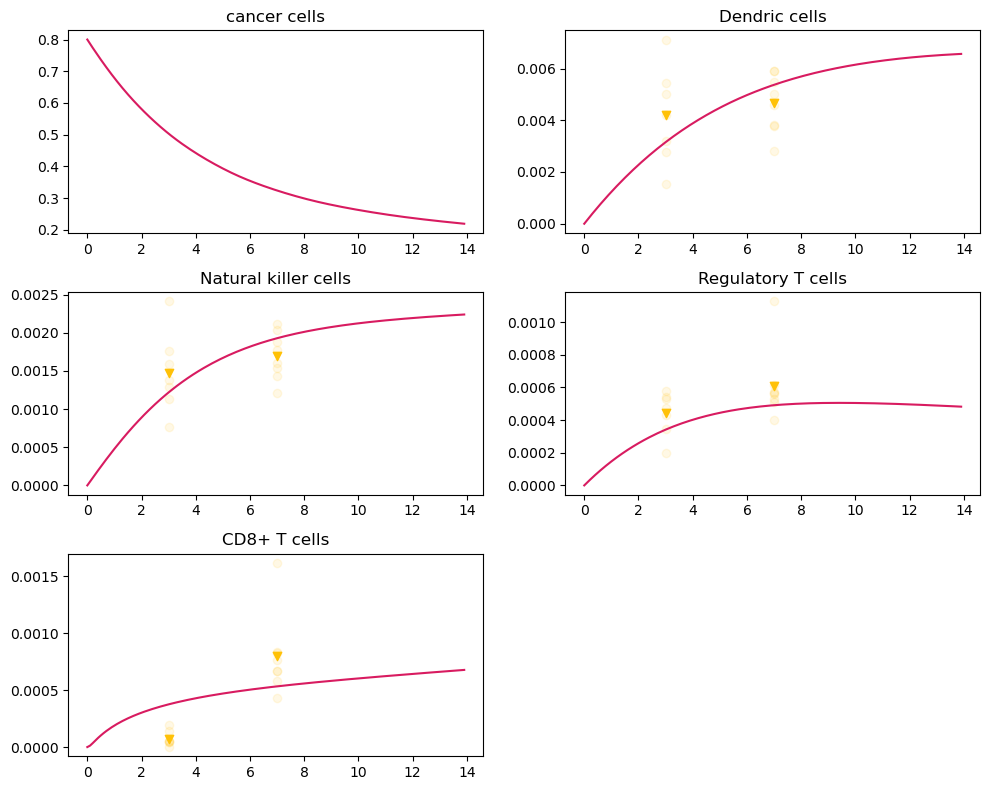

In [44]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = mutagen_best_params['C_init']
D_init     = mutagen_best_params['D_init']
N_init     = mutagen_best_params['N_init']
Tr_init    = mutagen_best_params['Tr_init']
T8_init    = mutagen_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_mutagen_times,scatter_mutagen_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_mutagen_times,scatter_mutagen_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_mutagen_times,scatter_mutagen_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_mutagen_times,scatter_mutagen_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [39]:
#Fitting non-mutagen treatment

In [ ]:

true_mutagen = np.array([no_mutagen_Ds[:2],no_mutagen_NKs[:2],no_mutagen_Tregs[:2],no_mutagen_T8s[:2]])

In [37]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4],'d_T8': [0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}


In [ ]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_mutagen)
        if minimum_distance>distance:
            minimum_distance = distance
            no_mutagen_best_params = params.copy()
            print(distance)
            print({k:no_mutagen_best_params[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:no_mutagen_best_params[k] for k in params_to_change.keys()})

17.660382220781
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
14.50098710408427
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
12.416190237885786
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
9.857406633066624
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
9.024275653286862
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
7.410508705553652
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
6.850112049105258
{'lambda_T8_comb': 1e-06, 'lambda_D

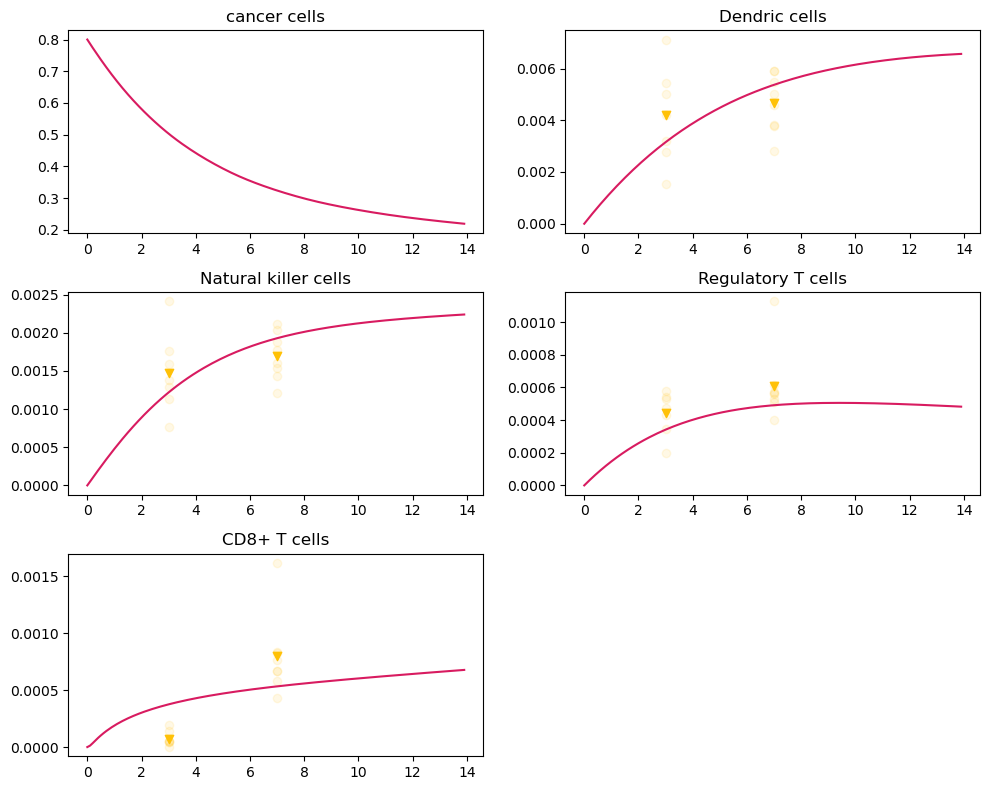

In [44]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = no_mutagen_best_params['C_init']
D_init     = no_mutagen_best_params['D_init']
N_init     = no_mutagen_best_params['N_init']
Tr_init    = no_mutagen_best_params['Tr_init']
T8_init    = no_mutagen_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],no_mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_no_mutagen_times,scatter_no_mutagen_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_no_mutagen_times,scatter_no_mutagen_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],no_mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_no_mutagen_times,scatter_no_mutagen_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],no_mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_no_mutagen_times,scatter_no_mutagen_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],no_mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [ ]:
#Fitting no treatment

In [ ]:
# objective_function_day3 = {'Ds':no_treatment_Ds[0],
#                           'NKs':no_treatment_NKs[0],
#                           'Tregs':no_treatment_Tregs[0],
#                           'T8s':no_treatment_T8s[0]}
# objective_function_day7 = {'Ds':no_treatment_Ds[1],
#                           'NKs':no_treatment_NKs[1],
#                           'Tregs':no_treatment_Tregs[1],
#                           'T8s':no_treatment_T8s[1]}
true_no_treatment = np.array([no_treatment_Ds[:2],no_treatment_NKs[:2],no_treatment_Tregs[:2],no_treatment_T8s[:2]])

In [37]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4],'d_T8': [0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}


In [ ]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_no_treatment)
        if minimum_distance>distance:
            minimum_distance = distance
            no_treatment_best_params = params.copy()
            print(distance)
            print({k:no_treatment_best_params[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:no_treatment_best_params[k] for k in params_to_change.keys()})

17.660382220781
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
14.50098710408427
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
12.416190237885786
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
9.857406633066624
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
9.024275653286862
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
7.410508705553652
{'lambda_T8_comb': 1e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 1e-05, 'sigma_N': 0.0005, 'K_Tr': 3e-05, 'd_N': 0.1}
6.850112049105258
{'lambda_T8_comb': 1e-06, 'lambda_D

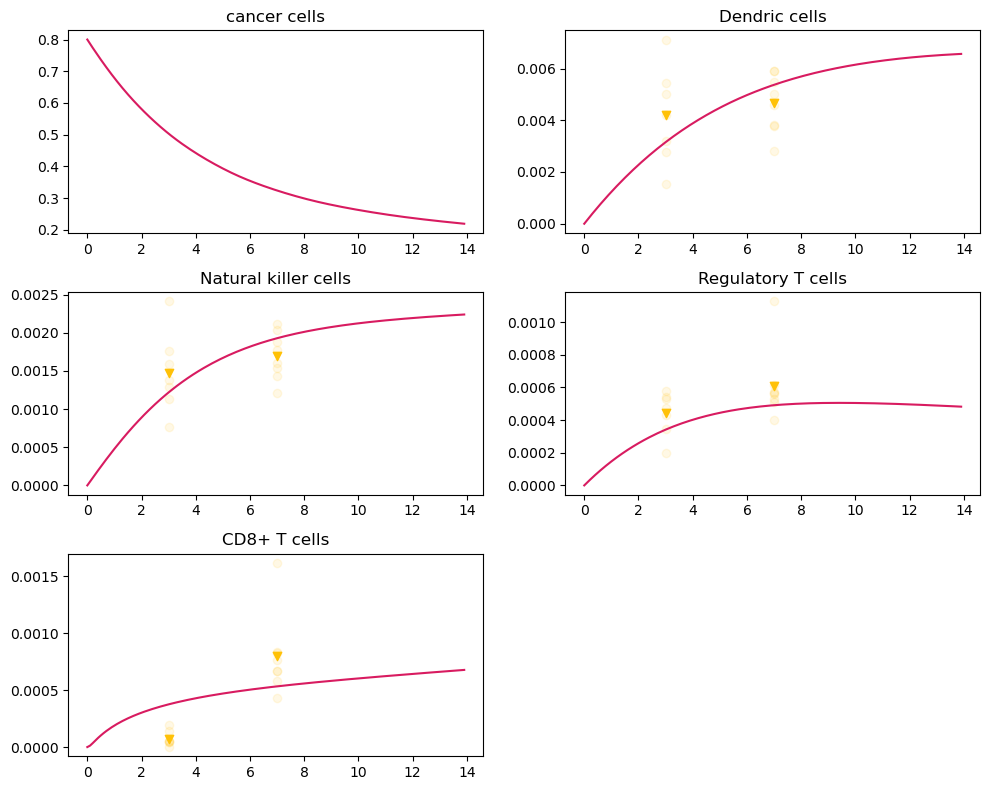

In [44]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = no_treatment_best_params['C_init']
D_init     = no_treatment_best_params['D_init']
N_init     = no_treatment_best_params['N_init']
Tr_init    = no_treatment_best_params['Tr_init']
T8_init    = no_treatment_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_treatment_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],no_treatment_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_no_treatment_times,scatter_no_treatment_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_no_treatment_times,scatter_no_treatment_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],no_treatment_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_no_treatment_times,scatter_no_treatment_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],no_treatment_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_no_treatment_times,scatter_no_treatment_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],no_treatment_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [91]:
# best_params.update({'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0013, 'd_T8': 1e-05, 'sigma_N': 0.00035, 'K_Tr': 2.25e-05, 'd_N': 0.22})

In [84]:
# UV
objective_function_day3 = {'Ds':UV_Ds[0],
                          'NKs':UV_NKs[0],
                          'Tregs':UV_Tregs[0],
                          'T8s':UV_T8s[0]}
objective_function_day7 = {'Ds':UV_Ds[1],
                          'NKs':UV_NKs[1],
                          'Tregs':UV_Tregs[1],
                          'T8s':UV_T8s[1]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2,0.1,1.0,2.0,3.0,4.0,5.0],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'lambda_Tr_comb':[1e-4,2e-4,3e-4,5e-4,1e-3,5e-3]}
params = best_params

In [85]:
import itertools

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
for combo in itertools.product(*values):
    iters+=1
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(sol.y)
        if minimum_distance>distance:
            minimum_distance = distance
            UV_best_params = params.copy()
            print(distance)
            print({k:best_params[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:best_params[k] for k in params_to_change.keys()})

52.21815681176209
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 5e-05, 'lambda_Tr_comb': 0.0001}
52.09968212696052
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 7.5e-05, 'lambda_Tr_comb': 0.0001}
52.04326478952634
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 9e-05, 'lambda_Tr_comb': 0.0001}
52.00791325507639
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.0001, 'lambda_Tr_comb': 0.0001}
51.67800591529983
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.0002, 'lambda_Tr_comb': 0.0001}
51.5135791174925
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.00025, 'lambda_Tr_comb': 0.0001}
51.430341424634044
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.000275, 'lambda_Tr_comb': 0.0001}
51.34625340772184
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.0003, 'lambda_Tr_comb': 0.0001}
51.26126527030471
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N

KeyboardInterrupt: 

In [93]:
print(UV_best_params['lambda_T8_comb'],UV_best_params['lambda_DC_comb'])
print(best_params['lambda_T8_comb'],best_params['lambda_DC_comb'])

0.002 0.0015
0.0001 0.0013


In [94]:
print(UV_best_params)
print(best_params)

{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0015, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 1e-05, 'lambda_T8_comb': 0.002, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0005, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}


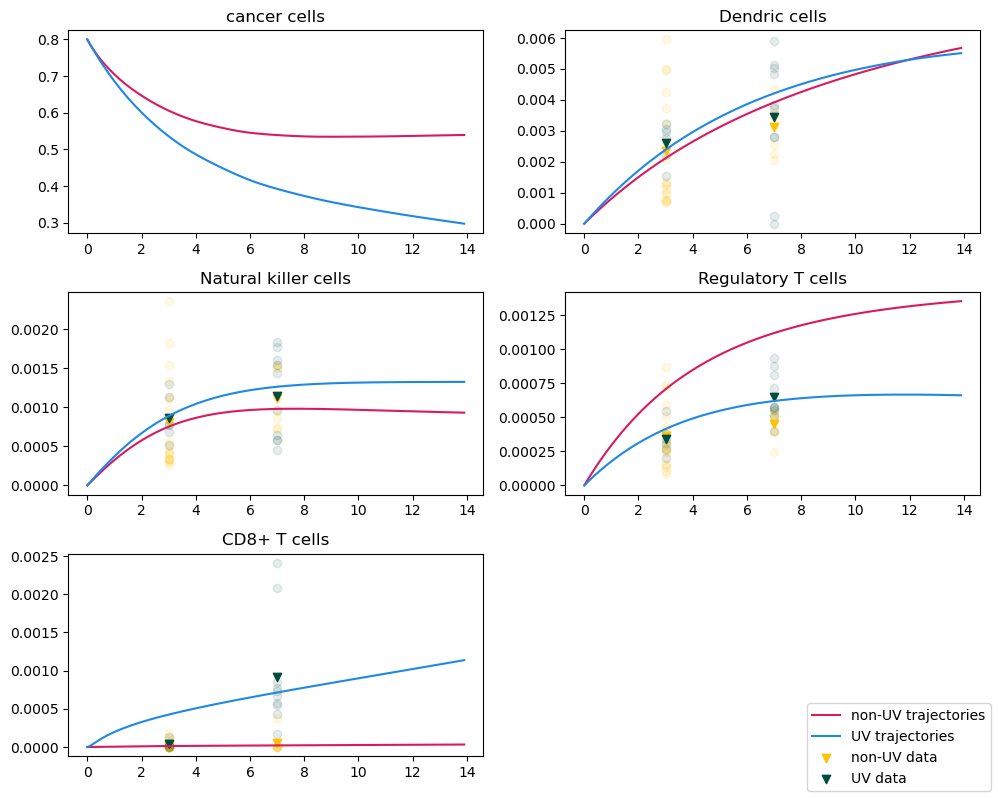

In [92]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)


tspan = (0.0,14.0,)
C_init     = best_params['C_init']
D_init     = best_params['D_init']
N_init     = best_params['N_init']
Tr_init    = best_params['Tr_init']
T8_init    = best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
sol_UV = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (UV_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
t_UV = sol_UV.t
y = sol.y
y_UV = sol_UV.y
import itertools

def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    )


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.plot(t,y_UV[0],color = c2)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1,label = 'non-UV trajectories')
D_cells.plot(t_UV,y_UV[1],color = c2,label = 'UV trajectories')
D_cells.set_title('Dendric cells')
D_cells.scatter(scatter_times,scatter_Ds,alpha=0.1,color = c3)
D_cells.scatter(scatter_UV_times,scatter_UV_Ds,alpha=0.1,color = c4)
D_cells.scatter([3.0,7.0],Ds[:2],alpha=1.0,marker ='v',color = c3,label = 'non-UV data')
D_cells.scatter([3.0,7.0],UV_Ds[:2],alpha=1.0,marker ='v',color = c4,label = 'UV data')

handles = []
labels = []
handles,labels = D_cells.get_legend_handles_labels()
# for handle,label in D_cells.get_legend_handles_labels():
#     handles.append(handle)
#     labels.append(label)
    
NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.plot(t_UV,y_UV[2],color = c2)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_times,scatter_NKs,alpha=0.1,color = c3)
NK_cells.scatter(scatter_UV_times,scatter_UV_NKs,alpha=0.1,color = c4)
NK_cells.scatter([3,7],NKs[:2],alpha=1.0,marker ='v',color = c3)
NK_cells.scatter([3,7],UV_NKs[:2],alpha=1.0,marker ='v',color = c4)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.plot(t_UV,y_UV[3],color = c2)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_times,scatter_Tregs,alpha=0.1,color = c3)
Treg.scatter(scatter_UV_times,scatter_UV_Tregs,alpha=0.1,color = c4)
Treg.scatter([3,7],Tregs[:2],alpha=1.0,marker ='v',color = c3)
Treg.scatter([3,7],UV_Tregs[:2],alpha=1.0,marker ='v',color = c4)

T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.plot(t_UV,y_UV[4],color = c2)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_times,scatter_T8s,alpha=0.1,color = c3)
T8.scatter(scatter_UV_times,scatter_UV_T8s,alpha=0.1,color = c4)
T8.scatter([3,7],T8s[:2],alpha=1.0,marker ='v',color = c3)
T8.scatter([3,7],UV_T8s[:2],alpha=1.0,marker ='v',color = c4)


extra_plot = ax[2,1]
extra_plot.set_visible(False)

fig.legend(handles,labels,loc = 'lower right')

plt.tight_layout()
plt.show()

In [12]:
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
# C0 = [0.8,0.0,0.0,0.00,0.0]

tspan = (0.0,50.0,)
import time

In [13]:
sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

TypeError: cancer_ode_parametrised() missing 1 required positional argument: 'p'

In [53]:
from matplotlib import pyplot as plt

NameError: name 'scatter_times' is not defined

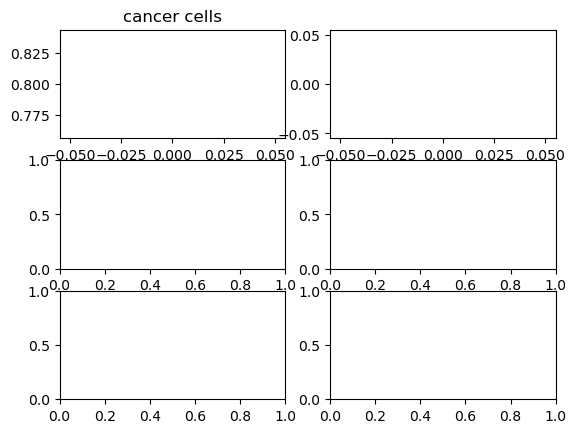

In [108]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],'b')
D_cells.scatter(scatter_times,scatter_Ds,'r')
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param = params
def cancer_ode_parametrised(t,y):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)

In [ ]:
param_grid = {
    'eta_8':[328.25]
    'eta_N':[300]
    'D0':[],
    'NK0':[],
    'Treg0':[],
    'T80':[0.0]
}

In [8]:
# parameters we are varying
y_data = np.array(
for param in param_grid:
    sigma_N,lambda_Tr,Tr_0,lambda_T8,T8_0,K_D,K_Tr=parm0 
    def cancer_ode_parametrised(t,y):
        return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
                   D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
                   beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
                  T8_0,K_D,K_Tr)
    tspan = (0.0,200.0,)
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

(5, 10)


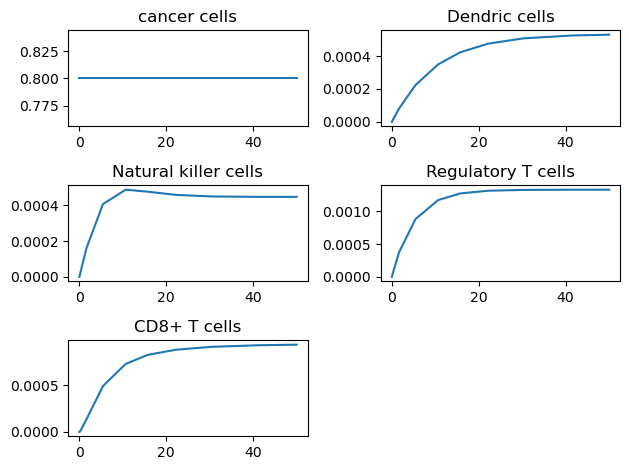

In [106]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [94]:
# SDEs
import sdeint
from sdeint import itoint
from sdeint import itoEuler

# need a noise term
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.0,0.2]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param,noise_NK_prod = params
def cancer_ode_parametrised(y,t):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,(1-noise_NK_prod)*sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)
def G(y,t):
    C,D,N,Tr,T8 = y
    return np.diag((noise_param*lambda_C*C*(1-C/C_M),0,noise_NK_prod*sigma_N,0,0,))

In [95]:
t = np.arange(tspan[0],tspan[1],0.001)
sol = itoEuler(cancer_ode_parametrised, G, C0, t)

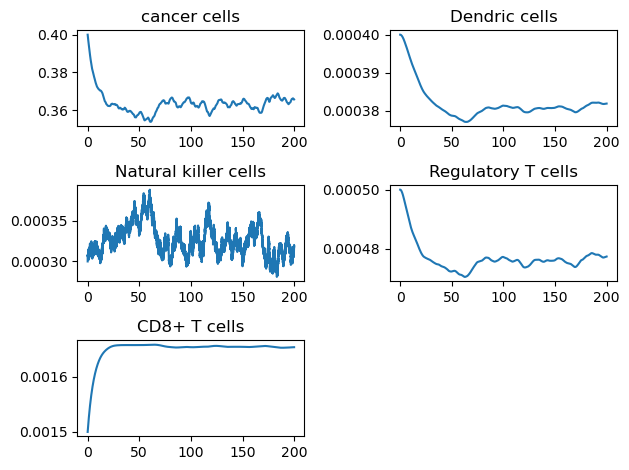

In [96]:
y = []
i = 0
for i in range(sol.shape[1]):
    y.append(sol[:,i])
fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()
